In [1]:
import numpy as np
from scipy.linalg import expm, pinvh, LinAlgError
from scipy.special import comb
from scipy.integrate import *

import matplotlib.pyplot as plt

from electron_integrals import *
from CI_physicist import *

Define functions

In [2]:
# Function to get reduced density matrices

def get_RDMs(num_orbitals, num_electrons, C):
    slater_dets = CIHamiltonian.get_slater_dets(num_orbitals, num_electrons)
    C_conj = C.conj()

    D = np.zeros((num_orbitals,)*2 , dtype=np.cdouble)
    d = np.zeros((num_orbitals,)*4, dtype=np.cdouble)

    for n, det_n in enumerate(slater_dets):
        for m, det_m in enumerate(slater_dets):
            num_differences = np.sum(np.abs(det_n-det_m))
            match(num_differences):
                case 0:
                    for p, n_p in enumerate(det_n):
                        D[p,p] += n_p*C_conj[m]*C[n]
                        for r, n_r in enumerate(det_n):
                            d[p,r,p,r] += n_p*n_r*C_conj[m]*C[n]
                            d[p,r,r,p] -= n_p*n_r*C_conj[m]*C[n] # Note the sign                 
                case 2:
                    p = np.flatnonzero(np.asarray((det_m-det_n)==1))[0]
                    q = np.flatnonzero(np.asarray((det_n-det_m)==1))[0]
                    gamma = (-1)**(np.sum(det_n[:q])+np.sum(det_m[:p]))
                    D[p,q] += gamma*C_conj[m]*C[n]

                    for r, n_r in enumerate(det_n):
                        val = gamma*n_r*C_conj[m]*C[n]
                        d[p,r,q,r] += val
                        d[r,p,q,r] -= val # Note the sign
                        d[p,r,r,q] -= val # Note the sign
                        d[r,p,r,q] += val

                case 4:
                    p,q = np.flatnonzero(np.asarray((det_m-det_n)==1))
                    r,s = np.flatnonzero(np.asarray((det_n-det_m)==1))
                    
                    gamma = np.sum(det_n[:r])
                    gamma += np.sum(det_n[:s])-1 # -1 since r<s 
                    gamma += np.sum(det_n[:q])-int(s<q)-int(r<q)
                    gamma += np.sum(det_n[:p])-int(s<p)-int(r<p) # No additional term since p<q

                    val = C_conj[m]*C[n]*(-1)**gamma
                    d[p,q,r,s] += val
                    d[q,p,r,s] -= val # Note the sign
                    d[p,q,s,r] -= val # Note the sign
                    d[q,p,s,r] += val

    return D, d


# Helper functions to put the problem on a form handled by standard SciPy ODE solvers 

def Cb_to_y(C, b):
    return np.concatenate([C.flatten(), b.flatten()])

def y_to_Cb(y, num_mctdhf_orbitals, num_spin_orbitals, num_electrons):
    num_slater_dets = int(comb(num_mctdhf_orbitals, num_electrons))

    C, b = np.split(y, [num_slater_dets])
    b = b.reshape((num_spin_orbitals, num_mctdhf_orbitals))

    return C, b

Define number of electrons and orbitals

In [8]:
# Number of orbitals (without spin)
num_orbitals = 201
# Number of electrons
num_electrons = 2
#Include spin?
include_spin = False

spin_factor = 1+int(include_spin)

num_spin_orbitals = spin_factor*num_orbitals

Calculate electron integrals

In [4]:
def kinetic_energy_mels(i, j, dx):
    return np.where(
        i==j,
        np.pi ** 2 / (6 * dx ** 2),
        (-1.0) ** (i_min_j := i - j) / (dx ** 2 * i_min_j **2),
    )

In [9]:
grid = np.linspace(-10, 10, num_orbitals)
dx = np.abs(grid[1] - grid[0])
inds=np.arange(len(grid))
potential = lambda x, omega=1: 0.5 * omega **2 * x ** 2

t = kinetic_energy_mels(inds[:, None], inds[None, :], dx)

h = t + np.diag(potential(grid))

if include_spin:
    #Add spin
    h = np.kron(h, np.eye(2,2))

g = shielded_coulomb(grid[:, None], grid[None, :], kappa=1, a=0.01)

if include_spin:
    #Add spin
    g = np.kron(g, np.einsum("pr,qs->pqrs",np.eye(2,2), np.eye(2,2)))

print('Sanity test, due to symmetry in g this should be zero:')
print(-g[2,1,1,0]+g[2,0,1,1]+g[1,1,2,0]-g[1,0,2,1])

Sanity test, due to symmetry in g this should be zero:


/tmp/ipykernel_9730/1501254881.py:5: RuntimeWarning: divide by zero encountered in divide
  (-1.0) ** (i_min_j := i - j) / (dx ** 2 * i_min_j **2),


IndexError: too many indices for array: array is 2-dimensional, but 4 were indexed

Solve using Slater-Condon 

In [7]:
z = np.zeros_like(g)

H = SlaterCondonHamiltonian(num_spin_orbitals, num_electrons, h, g).get_hamiltonian()
E, C = np.linalg.eigh(H)
print(E)
print(C[:,0].T@H@C[:,0])

D, d = get_RDMs(num_spin_orbitals, num_electrons, C[:,0])
E_rdm = np.einsum('pq, pq', D, h) + 0.5 * np.einsum('pqrs, pqrs', g, d)
print(E_rdm)

np.testing.assert_allclose(E[0], E_rdm)


IndexError: too many indices for array: array is 2-dimensional, but 4 were indexed

# Orbital equations

Define number of MCTDHF orbitals $(\{\ket{\phi_n(t)}\})$, initial b's (basis reduction coefficients),

$\ket{\phi_n(t)} = \sum_{k=1}^{N_b}b_{kn}(t)\ket{\psi_k}$,

and initial C's.


In [44]:
num_mctdhf_orbitals = 10
num_mctdhf_slater_dets = int(comb(num_mctdhf_orbitals, num_electrons))

# Distributed vales
#b_init = np.zeros((num_spin_orbitals, num_mctdhf_orbitals))
#a = int(num_spin_orbitals/num_mctdhf_orbitals)
#for i in range(num_mctdhf_orbitals):
#    b_init[a*i:a*(i+1), i] = np.ones(a)

# Identity
#b_init=np.eye(num_spin_orbitals, num_mctdhf_orbitals)

# Generate random orthonormal vectors
rng = np.random.default_rng()
r = rng.random((num_spin_orbitals, num_mctdhf_orbitals))
u, _, vh = np.linalg.svd(r, full_matrices=False)
b_init = (u@vh).astype(np.cdouble)*3

print(b_init)

# Ones as initial C
#C_init = np.ones((num_mctdhf_slater_dets), dtype=np.cdouble)

# Random initial C
C_init = rng.random(num_mctdhf_slater_dets).astype(np.cdouble)

#Normalize
C_init = np.divide(C_init, np.sqrt(C_init.T.conj()@C_init))
print(C_init)

[[-1.6166456 +0.j  1.46278168+0.j  1.96211202+0.j]
 [ 1.5570017 +0.j  1.35079684+0.j -0.41141045+0.j]
 [ 1.79095813+0.j -0.85941799+0.j  2.22327067+0.j]
 [ 0.86871843+0.j  2.07292508+0.j -0.19474451+0.j]]
[0.79650821+0.j 0.36964657+0.j 0.47847267+0.j]


Define callable class for the differential equations

In [85]:
class MCDTHF_imaginary_time:
    def __init__(self, h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons):
        self.h = h
        self.g = g
        self.num_mctdhf_orbitals = num_mctdhf_orbitals
        self.num_spin_orbitals = num_spin_orbitals
        self.num_electrons = num_electrons
        

    def __call__(self, t, y):
        
        C, b = y_to_Cb(y, self.num_mctdhf_orbitals, self.num_spin_orbitals, self.num_electrons)
        bc = b.conj()

        h_1 = np.einsum('jm, ij -> im', b, self.h)
        h_2 = np.einsum('in, im -> nm', bc, h_1)
        h_3 = np.einsum('in, nm -> in', b, h_2)

        b_dot = -(h_1-h_3)

        H = SlaterCondonHamiltonian(self.num_mctdhf_orbitals, self.num_electrons, h_2, np.zeros((self.num_mctdhf_orbitals, )*4)).get_hamiltonian()

        E = C.conj().T@H@C/(C.conj().T@C)

        C_dot = - (H-np.eye(num_mctdhf_orbitals)*E)@C

        return Cb_to_y(C_dot, b_dot)

Solve using ODE solver

In [86]:
#mctdhf_fun = MCDTHF(h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)
mctdhf_fun = MCDTHF_imaginary_time(h, z, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)

y_init = Cb_to_y(C_init, b_init)

Cs = np.copy(C_init).reshape(1,-1)

H = SlaterCondonHamiltonian(num_mctdhf_orbitals, num_electrons, h_2, np.zeros((num_mctdhf_orbitals, )*4)).get_hamiltonian()
Es = np.array(np.real(C_init.T@H@C_init))

t_init = 0
t_final = 30.0
solver = DOP853(mctdhf_fun, t_init, y_init, t_final)
#solver = RK45(mctdhf_fun, t_init, y_init, t_final)

while solver.status == 'running':
    msg = solver.step()

    C, b = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)
    # Normalize every step during imaginary time prop
    C = np.divide(C, np.sqrt(C.T.conj()@C))
    b = np.divide(b, np.sqrt(np.einsum('ij, ij -> j', b.conj(), b)))
  
    h_1 = np.einsum('jm, ij -> im', b, h)
    h_2 = np.einsum('in, im -> nm', b.conj(), h_1)
    h_3 = np.einsum('in, nm -> in', b, h_2)

    b_dot = -(h_1-h_3)

    H = SlaterCondonHamiltonian(num_mctdhf_orbitals, num_electrons, h_2, np.zeros((num_mctdhf_orbitals, )*4)).get_hamiltonian()

    D, d = get_RDMs(num_mctdhf_orbitals, num_electrons, C)
    #h_tilde = np.einsum('pk, qj, kj -> pq', b.conj(), b, h)
    #g_tilde = np.einsum('pi, qj, rk, sl, ijkl -> pqrs', b.conj(), b.conj(), b, b, g)
    #print(f"E = {np.einsum('pq, pq', D, h_2)}")# + 0.5 * np.einsum('pqrs, pqrs', g_tilde, d)}")

    Es = np.append(Es, np.real(C.conj().T@H@C))
    Cs = np.append(Cs, C.reshape(1,-1), axis=0)

    solver.y = Cb_to_y(C, b)
else:
    if solver.status != 'finished':
        raise(RuntimeError(msg))

/tmp/ipykernel_21723/3227808446.py:23: RuntimeWarning: overflow encountered in matmul
  E = C.conj().T@H@C/(C.conj().T@C)
/tmp/ipykernel_21723/3227808446.py:23: RuntimeWarning: invalid value encountered in matmul
  E = C.conj().T@H@C/(C.conj().T@C)


In [87]:
print(b_dot)

[[ 9.99974949e-01-0.j -0.00000000e+00-0.j -0.00000000e+00-0.j]
 [-2.11966822e-13-0.j -8.59389487e-14-0.j  1.95307218e-14-0.j]
 [-4.02247064e-26-0.j  1.01914460e-26-0.j -1.96903900e-26-0.j]
 [-2.85589386e-39-0.j -3.44121445e-39-0.j  2.41662826e-40-0.j]]


[[-1.00000000e+00+0.j  1.00000000e+00+0.j  1.00000000e+00+0.j]
 [ 1.05987394e-13+0.j  8.59432547e-14+0.j -1.95317004e-14+0.j]
 [ 1.34090193e-26+0.j -5.09610600e-27+0.j  9.84593496e-27+0.j]
 [ 7.14031602e-40+0.j  1.14718644e-39+0.j -8.05623485e-41+0.j]]
[0.80776401+0.j 0.20531689+0.j 0.55259595+0.j]


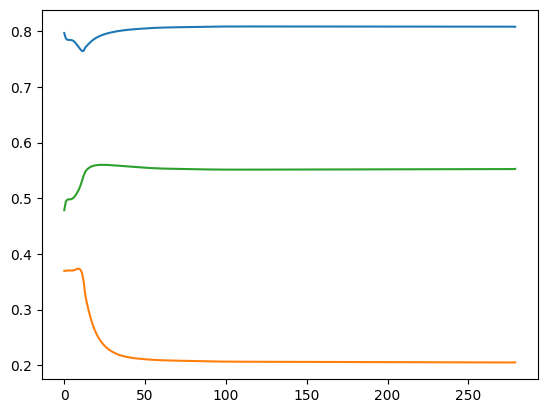

In [88]:
C_f, b_f = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)
print(b_f)
print(C_f)
plt.plot(np.real(Cs))
plt.show()

In [89]:
b_f

array([[-1.00000000e+00+0.j,  1.00000000e+00+0.j,  1.00000000e+00+0.j],
       [ 1.05987394e-13+0.j,  8.59432547e-14+0.j, -1.95317004e-14+0.j],
       [ 1.34090193e-26+0.j, -5.09610600e-27+0.j,  9.84593496e-27+0.j],
       [ 7.14031602e-40+0.j,  1.14718644e-39+0.j, -8.05623485e-41+0.j]])

In [75]:
h_2

array([[ 1.73349789+0.00000000e+00j,  0.0714674 +4.86209802e-01j,
        -0.72733638+2.13938709e-01j],
       [ 0.0714674 -4.86209802e-01j,  2.2969919 +0.00000000e+00j,
        -0.09060823-6.14348157e-01j],
       [-0.72733638-2.13938709e-01j, -0.09060823+6.14348157e-01j,
         1.63012058+1.73472348e-18j]])

In [76]:
D

array([[ 0.41913805+0.j        , -0.16097104-0.11653422j,
         0.43462579-0.1227594j ],
       [-0.16097104+0.11653422j,  0.0942217 +0.j        ,
        -0.13278798+0.16798638j],
       [ 0.43462579+0.1227594j , -0.13278798-0.16798638j,
         0.48664025+0.j        ]])

0.0012425384608472506


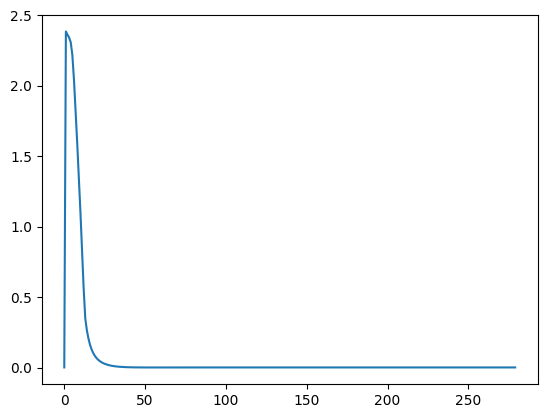

In [90]:
print(Es[-1])
plt.plot(Es)
plt.show()